# Step 3 — Understand and visualize the price data

Before calculating momentum, we inspect the downloaded data and make sure the two securities are comparable.

## What the columns mean

- **Open:** the first traded price of the regular trading session.
- **High:** the highest traded price during the session.
- **Low:** the lowest traded price during the session.
- **Close:** the final regular-session price.
- **Adjusted Close:** the close adjusted for events such as stock splits and dividends. We will use this for return calculations.
- **Volume:** the number of shares traded during the session.

AAPL and SPY have very different dollar prices, so a raw-price comparison can be misleading. We normalize both series to 100 on the first trading day. This shows how $100 invested in either security would have changed, ignoring transaction costs and fractional-share details.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "aapl_spy_2023-01-01_to_2025-01-01.csv"
prices = pd.read_csv(RAW_PATH, header=[0, 1], index_col=0, parse_dates=True)
prices.index.name = "Date"
prices.head()

Matplotlib is building the font cache; this may take a moment.


Price        Adj Close                   Close                    High  \
Ticker            AAPL         SPY        AAPL         SPY        AAPL   
Date                                                                     
2023-01-03  122.982719  364.134003  125.070000  380.820007  130.899994   
2023-01-04  124.251183  366.945129  126.360001  383.760010  128.660004   
2023-01-05  122.933533  362.757050  125.019997  379.380005  127.769997   
2023-01-06  127.456787  371.075806  129.619995  388.079987  130.289993   
2023-01-09  127.977943  370.865448  130.149994  387.859985  133.410004   

Price                          Low                    Open              \
Ticker             SPY        AAPL         SPY        AAPL         SPY   
Date                                                                     
2023-01-03  386.429993  124.169998  377.829987  130.279999  384.369995   
2023-01-04  385.880005  125.080002  380.000000  126.889999  383.179993   
2023-01-05  381.839996  124.760002  378.760010  127.129997  381.720001   
2023-01-06  389.250000  124.889999  379.410004  126.010002  382.609985   
2023-01-09  393.700012  129.889999  387.670013  130.470001  390.369995   

Price          Volume             
Ticker           AAPL        SPY  
Date                              
2023-01-03  112117500   74850700  
2023-01-04   89113600   85934100  
2023-01-05   80962700   76970500  
2023-01-06   87754700  104189600  
2023-01-09   70790800   73978100

In [2]:
quality_summary = pd.Series({
    "Trading days": len(prices),
    "First date": prices.index.min().date(),
    "Last date": prices.index.max().date(),
    "Duplicate dates": prices.index.duplicated().sum(),
    "Missing values": prices.isna().sum().sum(),
})
quality_summary

Trading days              502
First date         2023-01-03
Last date          2024-12-31
Duplicate dates             0
Missing values              0
dtype: object

In [3]:
adjusted_close = prices["Adj Close"][["AAPL", "SPY"]].copy()
adjusted_close.describe().round(2)

Ticker,AAPL,SPY
count,502.00,502.00
mean,187.90,470.07
std,28.06,66.51
min,122.93,362.76
25%,169.79,413.16
50%,183.14,460.35
75%,212.44,529.49
max,257.38,595.58


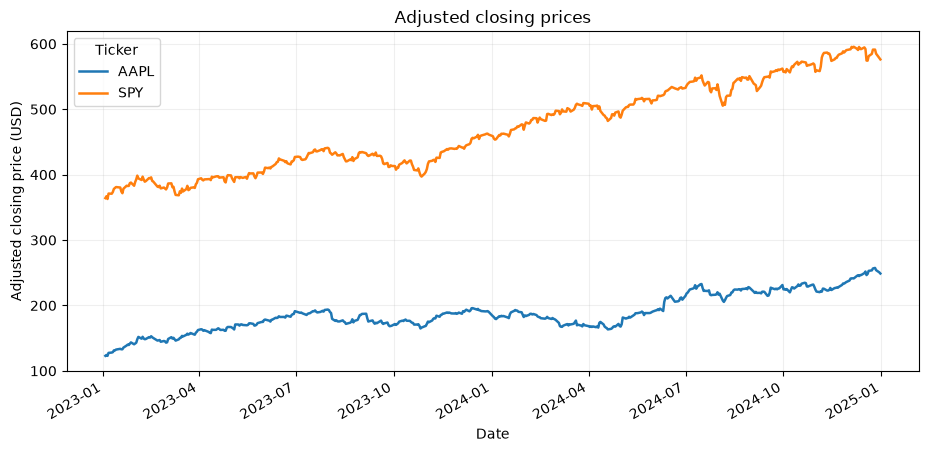

In [4]:
ax = adjusted_close.plot(figsize=(11, 5), linewidth=1.8)
ax.set_title("Adjusted closing prices")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted closing price (USD)")
ax.grid(alpha=0.2)
plt.show()

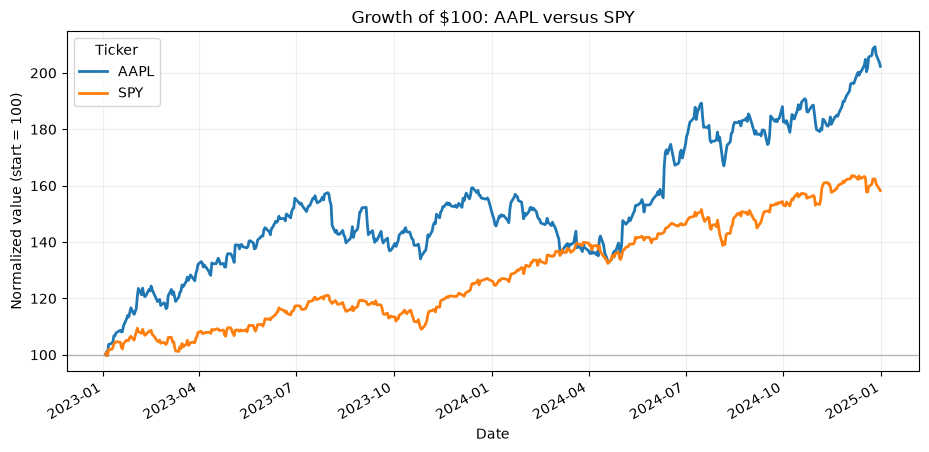

In [5]:
normalized = adjusted_close.div(adjusted_close.iloc[0]).mul(100)
ax = normalized.plot(figsize=(11, 5), linewidth=2)
ax.axhline(100, color="gray", linewidth=1, alpha=0.5)
ax.set_title("Growth of $100: AAPL versus SPY")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized value (start = 100)")
ax.grid(alpha=0.2)
plt.show()

## How to interpret the normalized chart

A value of 125 means that the security gained 25% from the beginning of this dataset. The chart is descriptive—it tells us what happened over the full period, but does not yet tell us whether five-day momentum predicts future outperformance.